In [1]:
#!pip install alpaca-py #newer base
#!pip install alpaca-trade-api
#!pip install mplfinance

In [2]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from datetime import datetime
import pandas as pd


In [3]:
# Alpaca API credentials
API_KEY = "PKP6G2PCSLR7KABZBU9Z"
API_SECRET = "mPNf9KoilrmoMdz4MedQdeaZWxda3D1YjgCIJbjd"

client = StockHistoricalDataClient(API_KEY, API_SECRET)

In [4]:
SUPPORTED_TIMEFRAMES = {
    "Minute": [1, 5, 15],
    "Hour": [1],
    "Day": [1]
}
#i belive i can call multiple tickers at the same time
def get_stock_data(symbol: str, start_date: str, end_date: str,
                   timeframe_unit: str = "Day", multiplier: int = 1):
    if timeframe_unit not in SUPPORTED_TIMEFRAMES:
        raise ValueError(f"Unsupported timeframe unit: {timeframe_unit}")
    if multiplier not in SUPPORTED_TIMEFRAMES[timeframe_unit]:
        raise ValueError(f"Unsupported multiplier '{multiplier}' for '{timeframe_unit}'")

    unit_enum = TimeFrameUnit[timeframe_unit]
    alpaca_timeframe = TimeFrame(multiplier, unit_enum)

    request_params = StockBarsRequest(
        symbol_or_symbols=[symbol],
        timeframe=alpaca_timeframe,
        start=datetime.strptime(start_date, "%Y-%m-%d"),
        end=datetime.strptime(end_date, "%Y-%m-%d")
    )

    bars = client.get_stock_bars(request_params)
    df = bars.df

    # Handle both flat and MultiIndex column cases
    if isinstance(df.columns, pd.MultiIndex):
        if symbol in df.columns.levels[0]:
            df = df.xs(symbol, axis=1, level=0)
        else:
            raise KeyError(f"Symbol '{symbol}' not found in returned data columns.")
    
    # Check for required columns and raise helpful error if missing
    required_cols = ['open', 'high', 'low', 'close', 'volume']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in data: {missing}\nAvailable columns: {df.columns.tolist()}")

    return df[required_cols]

#df = get_stock_data("AAPL", "2024-05-01", "2024-05-10")
#print(df)

In [5]:
def plot_candlestick_with_volume(df, symbol: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})

    # Prepare data for candlestick
    quotes = []
    for idx, (multi_idx, row) in enumerate(df.iterrows()):
        # multi_idx is a tuple: (symbol, timestamp)
        timestamp = multi_idx[1]
        quotes.append((
            mdates.date2num(timestamp),
            row['open'],
            row['high'],
            row['low'],
            row['close']
        ))

    # Candlestick chart
    candlestick_ohlc(ax1, quotes, width=0.6, colorup='g', colordown='r', alpha=0.8)
    ax1.set_title(f'{symbol} Candlestick Chart')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # Volume bar chart
    ax2.bar([multi_idx[1] for multi_idx in df.index], df['volume'], color='gray', width=0.6)
    ax2.set_ylabel('Volume')
    ax2.grid(True)

    # Format x-axis with dates
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


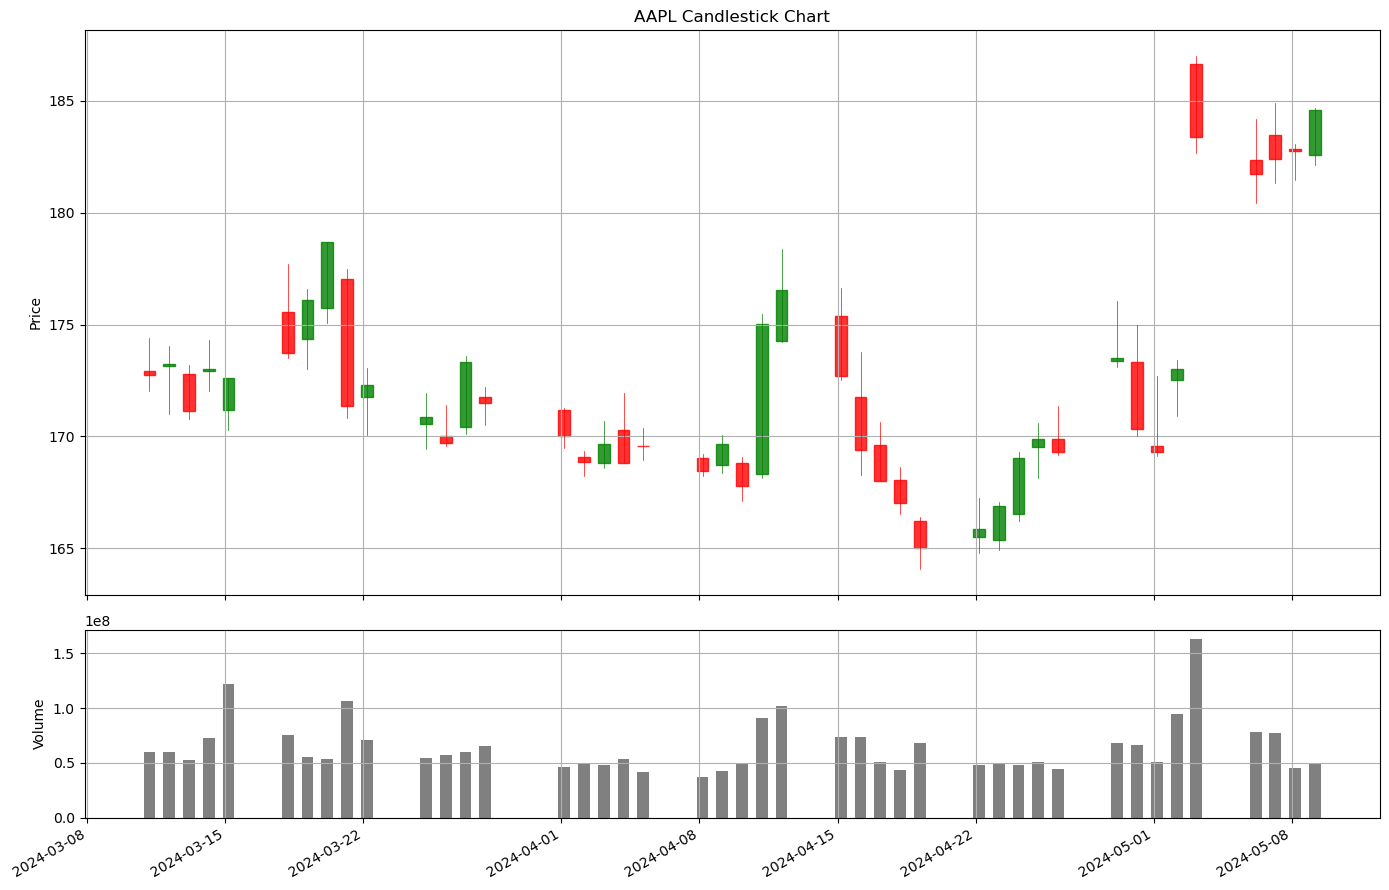

In [6]:
# Example usage
symbol = "AAPL"
start_date = "2024-03-10"
end_date = "2024-05-10"
timeframe_unit = "Day"  # or "Minute", "Hour"
multiplier = 1
# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)
# Plot candlestick chart with volume
plot_candlestick_with_volume(df, symbol)